In [1]:
import pandas as pd

In [25]:
df = pd.read_csv('Social_Network_Ads.csv')

In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df.drop(columns=['User ID','Gender', 'Purchased'], inplace=True)

In [5]:
df.head()

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000


In [6]:
age_mean = df['Age'].mean()
age_std = df['Age'].std()
salary_mean = df['EstimatedSalary'].mean()
salary_std = df['EstimatedSalary'].std()

In [7]:
# Implement standardization
df['age_scaled'] = (df['Age']-age_mean)/age_std

In [8]:
df.age_scaled.mean()

np.float64(-1.4210854715202004e-16)

In [9]:
round(df['age_scaled'].mean(), 2)

np.float64(-0.0)

In [10]:
df['age_scaled'].std()

np.float64(1.0)

## I tryed 2-3 times and then after searching on google i get to know i was getting correce output -1.4210854715202004e-16 which is nothing else but 0 itself.
## lets do for salary also!!!!!

In [11]:
df['salary_scaled'] = (df['EstimatedSalary']-salary_mean)/salary_std

In [12]:
df['salary_scaled'].mean()

np.float64(3.552713678800501e-17)

In [13]:
round(df['salary_scaled'].mean(), 2)

np.float64(0.0)

In [14]:
df['salary_scaled'].std()

np.float64(0.9999999999999999)

### Its almost 1.

In [15]:
round(df.describe(),2)

,Age,EstimatedSalary,age_scaled,salary_scaled
count,400.00,400.00,400.00,400.00
mean,37.66,69742.50,-0.00,0.00
std,10.48,34096.96,1.00,1.00
min,18.00,15000.00,-1.87,-1.61
25%,29.75,43000.00,-0.75,-0.78
50%,37.00,70000.00,-0.06,0.01
75%,46.00,88000.00,0.80,0.54
max,60.00,150000.00,2.13,2.35


## We cam clearly see the difference befor the stadardization and after the standardization.

# lets check the geometry of scaled and not scaled

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'After')

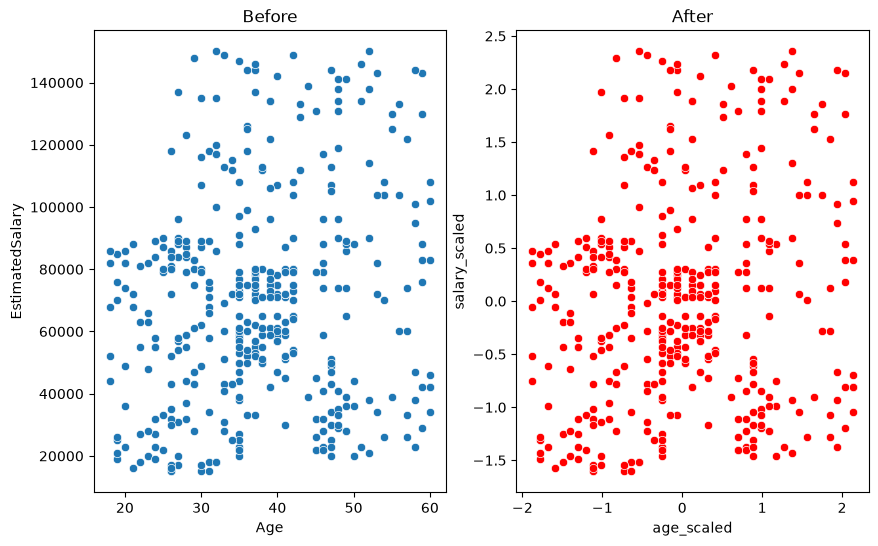

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='EstimatedSalary', ax=axes[0])
axes[0].set_title('Before')
sns.scatterplot(data=df, x='age_scaled', y='salary_scaled', ax=axes[1], color='red')
axes[1].set_title('After')

# Lets check individual disctribution

<Axes: xlabel='age_scaled', ylabel='Density'>

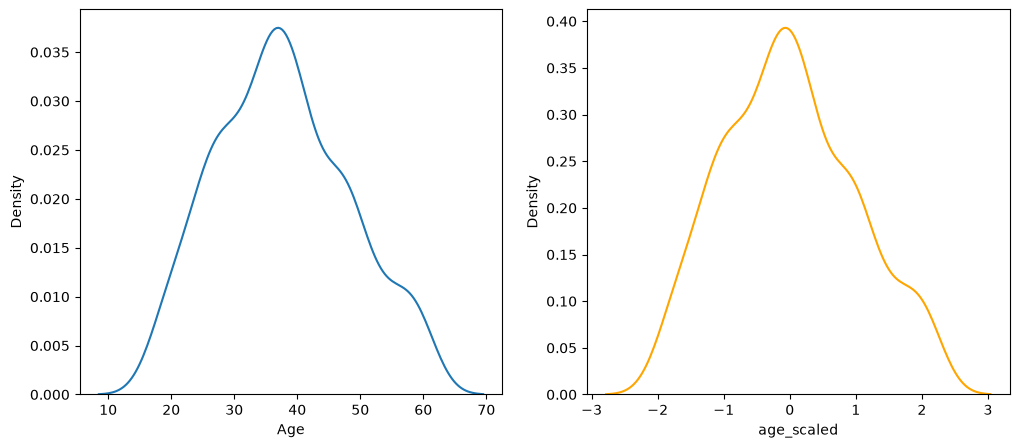

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(df['Age'], ax=axes[0])
sns.kdeplot(df['age_scaled'], ax=axes[1], color='orange')

<Axes: xlabel='salary_scaled', ylabel='Density'>

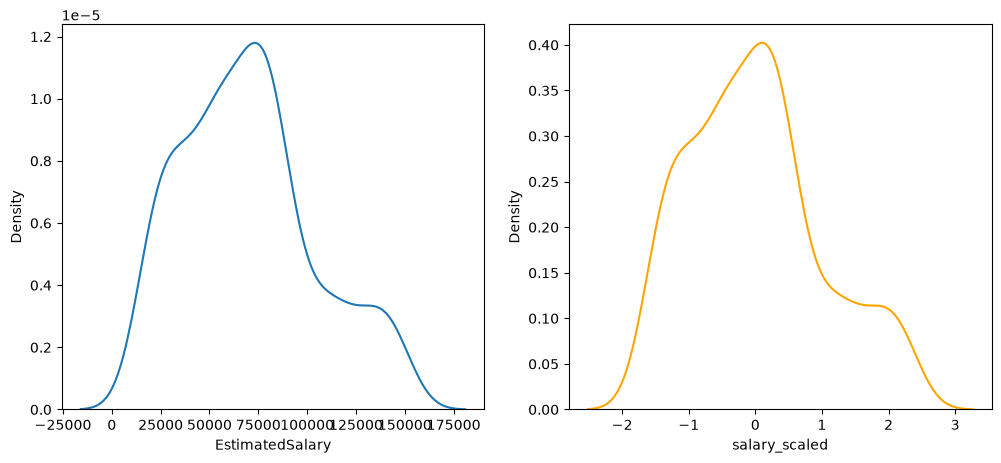

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.kdeplot(df['EstimatedSalary'], ax=axes[0])
sns.kdeplot(df['salary_scaled'], ax=axes[1], color='orange')

## There is no distribution differennce in between unscaled and scaled data

# Using Scikit-learn

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [29]:
# Fresh df
df.drop(columns=['User ID', 'Gender'], inplace=True)

In [30]:
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [31]:
X_train, X_test, y_train, y_test = train_test_split(df.drop(columns='Purchased'),
                                                   df['Purchased'],
                                                   test_size=0.3,
                                                   random_state=0)

In [33]:
X_train.shape, X_test.shape

((280, 2), (120, 2))

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [39]:
X_train.Age.mean()

np.float64(37.864285714285714)

In [46]:
round(X_train_scaled[:, :1].mean(),2), round(X_train_scaled[:, 1:].mean(),2)

(np.float64(0.0), np.float64(0.0))

In [47]:
round(X_train_scaled[:, :1].std(),2), round(X_train_scaled[:, 1:].std(),2)

(np.float64(1.0), np.float64(1.0))